## Observations

- The PlantVillage dataset is well organized into separate folders representing different crop diseases.
- Each folder contains images belonging to a single disease class, making the dataset suitable for supervised image classification.
- The dataset contains multiple disease categories with a sufficient number of images for model training.
- Image dimensions vary across the dataset; therefore, all images are resized to 224 × 224 pixels during preprocessing to maintain consistency.
- The dataset is clean, labelled, and appropriate for transfer learning using MobileNetV2.
- The class distribution is reasonably balanced, reducing the risk of significant class imbalance during training.

In [42]:
image_widths = []
image_heights = []

for disease in classes:

    disease_path = os.path.join(dataset_path, disease)

    for image_name in os.listdir(disease_path):

        if image_name.lower().endswith((".jpg", ".jpeg", ".png")):

            image_path = os.path.join(disease_path, image_name)

            with Image.open(image_path) as img:

                width, height = img.size

                image_widths.append(width)

                image_heights.append(height)

print("Minimum Width :", min(image_widths))
print("Maximum Width :", max(image_widths))
print("Minimum Height:", min(image_heights))
print("Maximum Height:", max(image_heights))

print("\nAverage Width :", round(np.mean(image_widths),2))
print("Average Height:", round(np.mean(image_heights),2))

Minimum Width : 256
Maximum Width : 256
Minimum Height: 256
Maximum Height: 256

Average Width : 256.0
Average Height: 256.0


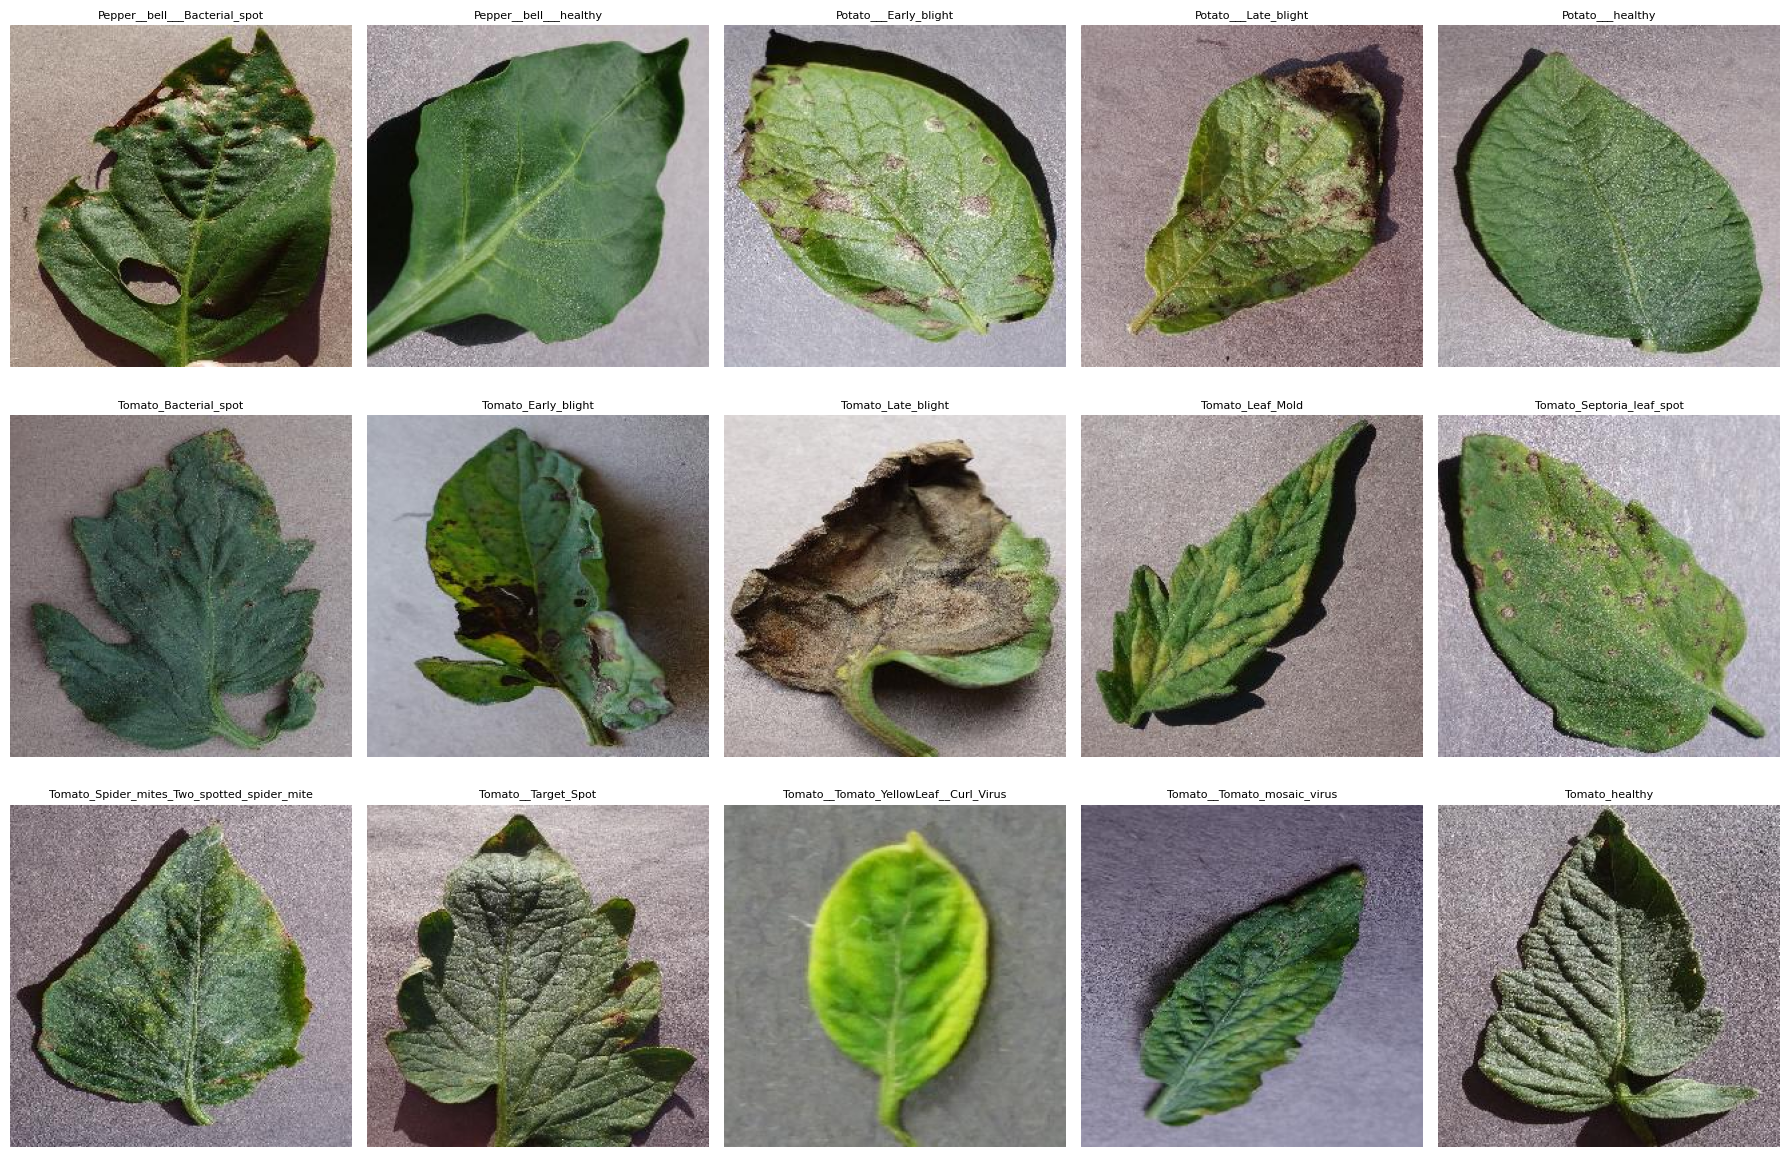

In [43]:
fig, axes = plt.subplots(3, 5, figsize=(18, 12))

axes = axes.flatten()

for i, disease in enumerate(classes):

    disease_path = os.path.join(dataset_path, disease)

    image_name = random.choice(os.listdir(disease_path))

    image_path = os.path.join(disease_path, image_name)

    image = Image.open(image_path)

    axes[i].imshow(image)

    axes[i].set_title(disease, fontsize=8)

    axes[i].axis("off")

plt.tight_layout()

plt.show()

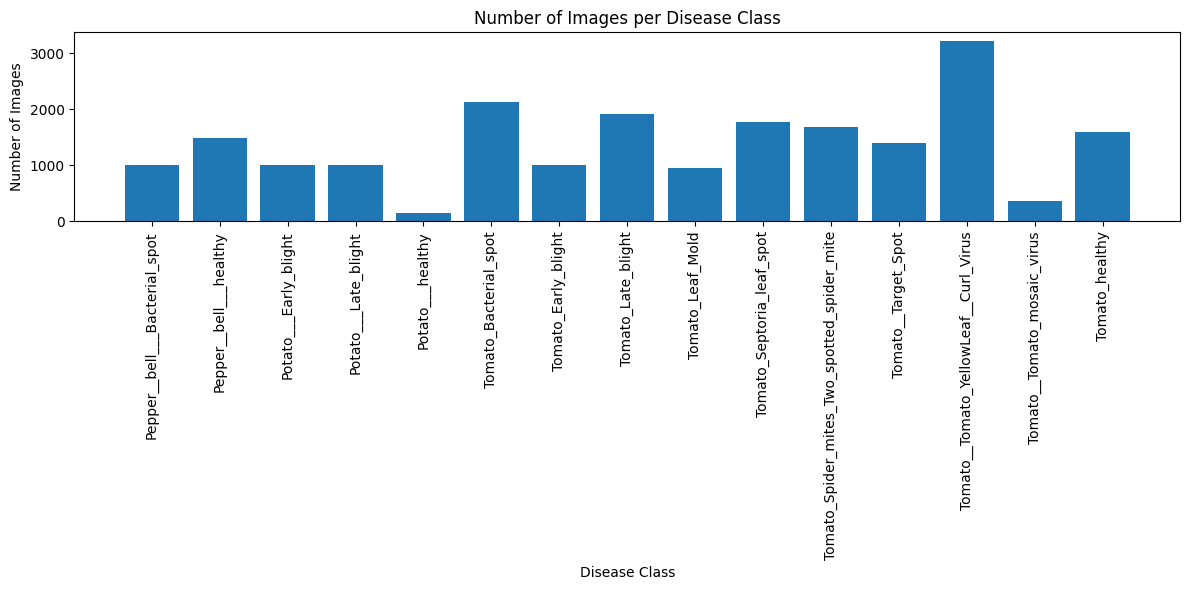

In [44]:
plt.figure(figsize=(12,6))

plt.bar(df["Disease Class"], df["Number of Images"])

plt.xticks(rotation=90)

plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Number of Images per Disease Class")

plt.tight_layout()

plt.savefig("../reports/class_distribution.png")

plt.show()

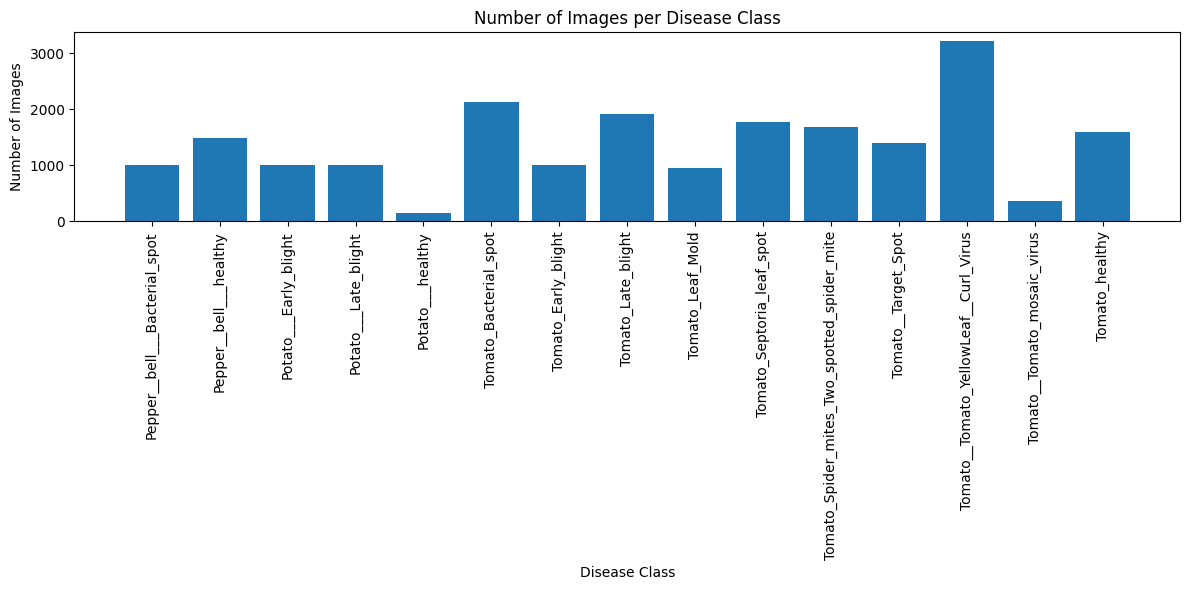

In [45]:
plt.figure(figsize=(12,6))

plt.bar(df["Disease Class"], df["Number of Images"])

plt.xticks(rotation=90)

plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Number of Images per Disease Class")

plt.tight_layout()
plt.show()

In [46]:
print("Total Classes :", len(df))
print("Total Images  :", df["Number of Images"].sum())
print("Average Images per Class :", round(df["Number of Images"].mean(), 2))

Total Classes : 15
Total Images  : 20638
Average Images per Class : 1375.87


In [47]:
df = pd.DataFrame(
    image_counts.items(),
    columns=["Disease Class", "Number of Images"]
)

df

,Disease Class,Number of Images
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,Potato___Early_blight,1000
3,Potato___Late_blight,1000
4,Potato___healthy,152
5,Tomato_Bacterial_spot,2127
6,Tomato_Early_blight,1000
7,Tomato_Late_blight,1909
8,Tomato_Leaf_Mold,952
9,Tomato_Septoria_leaf_spot,1771


In [48]:
image_counts = {}

for disease in classes:
    disease_path = os.path.join(dataset_path, disease)

    image_counts[disease] = len([
        img for img in os.listdir(disease_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

image_counts

{'Pepper__bell___Bacterial_spot': 997,
 'Pepper__bell___healthy': 1478,
 'Potato___Early_blight': 1000,
 'Potato___Late_blight': 1000,
 'Potato___healthy': 152,
 'Tomato_Bacterial_spot': 2127,
 'Tomato_Early_blight': 1000,
 'Tomato_Late_blight': 1909,
 'Tomato_Leaf_Mold': 952,
 'Tomato_Septoria_leaf_spot': 1771,
 'Tomato_Spider_mites_Two_spotted_spider_mite': 1676,
 'Tomato__Target_Spot': 1404,
 'Tomato__Tomato_YellowLeaf__Curl_Virus': 3208,
 'Tomato__Tomato_mosaic_virus': 373,
 'Tomato_healthy': 1591}

In [49]:
classes = sorted(os.listdir(dataset_path))

print("Total Disease Classes:", len(classes))

for disease in classes:
    print(disease)

Total Disease Classes: 15
Pepper__bell___Bacterial_spot
Pepper__bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato__Tomato_mosaic_virus
Tomato_healthy


In [50]:
dataset_path = "../datasets/PlantVillage"

print("Dataset Path:", dataset_path)
print("Exists:", os.path.exists(dataset_path))

Dataset Path: ../datasets/PlantVillage
Exists: True


In [51]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

# AgriSense - Exploratory Data Analysis (EDA)

## Crop Disease Detection using PlantVillage Dataset

### Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the PlantVillage dataset before training the deep learning model. This analysis helps understand the dataset structure, class distribution, image characteristics, and preprocessing requirements.